<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Disk_Magnet_Field_MagPyLib_and_K3D_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!pip install -q "numpy>=2.0" k3d trimesh magpylib
!pip install -q ipywidgets

# Enable Colab widget support
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
"""Render a material-configurable magnetic field around a disk magnet."""

import itertools
import sys

import k3d
import magpylib as magpy
import matplotlib.pyplot as plt
import numpy as np

from google.colab import output
from IPython.display import HTML, display


# ------------------------------------------------------------
# COLAB CONFIGURATION
# ------------------------------------------------------------

output.enable_custom_widget_manager()


def configure_k3d_snapshot_protocol():
    """Enable K3D text serialization where supported."""
    switch_protocol = getattr(
        k3d,
        "switch_to_text_protocol",
        None,
    )

    if callable(switch_protocol):
        switch_protocol()


configure_k3d_snapshot_protocol()


# ------------------------------------------------------------
# CONTROL KNOBS - DISK GEOMETRY
# ------------------------------------------------------------

# Magpylib Cylinder dimensions follow:
#
#     dimension = (diameter, height)
#
# The default cylinder axis is z.
DISK_DIAMETER_CM = 4.0
DISK_THICKNESS_CM = 1.0

# Number of circumferential facets used only by the displayed disk.
DISK_RADIAL_SEGMENTS = 96


# ------------------------------------------------------------
# CONTROL KNOBS - MAGNETIC MATERIAL
# ------------------------------------------------------------

# Descriptive material label used in diagnostics and the K3D object name.
DISK_MATERIAL_NAME = "NdFeB N55 (sintered)"

# Select how the homogeneous Magpylib source strength is specified:
#
#     "remanence"     -> use datasheet Br with temperature and working-point
#                         corrections. This is the preferred material-oriented
#                         mode for a permanent magnet.
#
#     "polarization"  -> use a directly specified effective polarization J.
#
#     "magnetization" -> use a directly specified magnetization M and convert
#                         it with J = mu0 M.
DISK_MATERIAL_INPUT_MODE = "remanence"

# Local magnetization direction. The vector is normalized automatically.
# [0, 0, 1] points normal to the broad disk faces.
DISK_MAGNETIZATION_DIRECTION = np.array(
    [0.0, 0.0, 1.0],
    dtype=np.float64,
)

# --- Remanence mode ----------------------------------------------------------

# Nominal N55 remanent flux density Br at 20 C. Arnold Magnetic Technologies
# lists 1.46 T minimum, 1.49 T nominal, and 1.52 T maximum for its N55 grade.
DISK_REMANENCE_T_AT_REFERENCE = 1.49

DISK_REFERENCE_TEMPERATURE_C = 20.0
DISK_OPERATING_TEMPERATURE_C = 20.0

# N55 reversible temperature coefficient of Br near room temperature.
# -0.0012 per C corresponds to -0.12 %/C.
DISK_BR_TEMPERATURE_COEFFICIENT_PER_C = -0.0012

# Mean working-point correction applied after the Br temperature correction.
# 1.00 reproduces the ideal homogeneous Br approximation. Values below unity
# represent mean self-demagnetization or a working point read from a datasheet.
DISK_WORKING_POINT_FACTOR = 1.00

# --- Direct polarization mode -----------------------------------------------

# Effective homogeneous polarization J in tesla. Used only if
# DISK_MATERIAL_INPUT_MODE == "polarization".
DISK_EFFECTIVE_POLARIZATION_T = 1.49

# --- Direct magnetization mode ----------------------------------------------

# Homogeneous magnetization M in A/m. Used only if
# DISK_MATERIAL_INPUT_MODE == "magnetization".
DISK_MAGNETIZATION_A_PER_M = 1.1857e6

# --- Engineering metadata ---------------------------------------------------

# Representative N55 room-temperature material metadata. The magnetic field
# source itself is driven by the resolved homogeneous polarization above.
# Manufacturer-specific values can vary with processing, dimensions, and coating.
DISK_RELATIVE_RECOIL_PERMEABILITY = None

# Arnold N55 data: HcJ >= 876 kA/m and nominal HcB = 935 kA/m.
DISK_INTRINSIC_COERCIVITY_A_PER_M = 876.0e3
DISK_NORMAL_COERCIVITY_A_PER_M = 935.0e3

# Arnold N55 nominal maximum energy product and Curie temperature.
DISK_MAX_ENERGY_PRODUCT_KJ_PER_M3 = 422.0
DISK_CURIE_TEMPERATURE_C = 310.0

# Representative upper service temperature for standard N55 grade.
DISK_MAX_OPERATING_TEMPERATURE_C = 60.0

# A separate saturation-polarization value is unavailable in the selected N55
# datasheet, so the optional saturation guard is disabled by default.
DISK_SATURATION_POLARIZATION_T = None

# Arnold N55 density: 7.6 g/cm^3 = 7600 kg/m^3.
DISK_DENSITY_KG_PER_M3 = 7600.0


# ------------------------------------------------------------
# CONTROL KNOBS - FIELD DOMAIN
# ------------------------------------------------------------

X_MIN_CM = -6.0
X_MAX_CM = 6.0

Y_MIN_CM = -6.0
Y_MAX_CM = 6.0

Z_MIN_CM = -6.0
Z_MAX_CM = 6.0

# Suppress field samples originating inside the physical disk.
EXCLUDE_INTERNAL_VECTORS = True


# ------------------------------------------------------------
# CONTROL KNOBS - ADAPTIVE 3D ARROW SPACING
# ------------------------------------------------------------

# Generate a dense, non-Cartesian candidate cloud first. A mirrored Halton
# sequence avoids the visibly equidistant lattice of a Cartesian mesh and
# preserves inversion symmetry about the disk center.
ADAPTIVE_CANDIDATE_POINTS = 7000
ADAPTIVE_HALTON_SKIP = 37

# Local origin-to-origin spacing in centimeters. Stronger fields receive the
# smaller spacing so more directional detail survives close to the magnet.
ADAPTIVE_SPACING_MIN_CM = 0.62
ADAPTIVE_SPACING_MAX_CM = 1.72

# Percentile bounds keep a few extreme near-surface field samples from
# controlling the entire spacing distribution.
ADAPTIVE_FIELD_MIN_PERCENTILE = 3.0
ADAPTIVE_FIELD_MAX_PERCENTILE = 97.0

# Power-law response of sampling density to magnetic flux density magnitude.
# 1.00 is linear. Values below unity preserve more intermediate-field detail.
ADAPTIVE_SPACING_EXPONENT = 0.60

# Strong-field samples are considered first during adaptive blue-noise
# selection. Far-field coverage is still retained wherever the local spacing
# criterion allows another sample.
ADAPTIVE_PRIORITIZE_STRONG_FIELD = True

SHOW_ADAPTIVE_SAMPLING_DIAGNOSTICS = True


# ------------------------------------------------------------
# CONTROL KNOBS - FIELD-DEPENDENT GLYPH SIZE
# ------------------------------------------------------------

# Robust percentile bounds prevent a few extreme near-surface values from
# compressing the visible size variation across the rest of the field.
GLYPH_FIELD_MIN_PERCENTILE = 2.0
GLYPH_FIELD_MAX_PERCENTILE = 98.0

# Power-law response of 3D arrow size to magnetic flux density magnitude.
#
# 1.00 gives a linear response.
# < 1.00 gives weak and intermediate fields more visible size separation.
# > 1.00 emphasizes only the strongest fields.
GLYPH_SIZE_EXPONENT = 0.65

# One master scale controls every linear dimension of each 3D arrow.
# This preserves the arrow aspect ratio as field strength changes.
GLYPH_SCALE_MIN = 0.35
GLYPH_SCALE_MAX = 1.80

# Reference arrow geometry at scale = 1.
BASE_ARROW_LENGTH_CM = 0.75
BASE_ARROW_SHAFT_WIDTH_CM = 0.115
BASE_ARROW_CONE_LENGTH_CM = 0.22
BASE_ARROW_CONE_RADIUS_CM = 0.14

# Global radial scale for the complete arrow. This is the primary thickness
# control knob. Values below 1.0 make both the cylindrical shaft and cone tip
# slimmer without changing arrow length.
ARROW_DIAMETER_SCALE = 0.60

# Derived extrema used by diagnostics.
ARROW_LENGTH_MIN_CM = BASE_ARROW_LENGTH_CM * GLYPH_SCALE_MIN
ARROW_LENGTH_MAX_CM = BASE_ARROW_LENGTH_CM * GLYPH_SCALE_MAX

ARROW_SHAFT_WIDTH_MIN_CM = (
    BASE_ARROW_SHAFT_WIDTH_CM
    * GLYPH_SCALE_MIN
    * ARROW_DIAMETER_SCALE
)
ARROW_SHAFT_WIDTH_MAX_CM = (
    BASE_ARROW_SHAFT_WIDTH_CM
    * GLYPH_SCALE_MAX
    * ARROW_DIAMETER_SCALE
)

ARROW_CONE_LENGTH_MIN_CM = (
    BASE_ARROW_CONE_LENGTH_CM
    * GLYPH_SCALE_MIN
)
ARROW_CONE_LENGTH_MAX_CM = (
    BASE_ARROW_CONE_LENGTH_CM
    * GLYPH_SCALE_MAX
)

ARROW_CONE_RADIUS_MIN_CM = (
    BASE_ARROW_CONE_RADIUS_CM
    * GLYPH_SCALE_MIN
    * ARROW_DIAMETER_SCALE
)
ARROW_CONE_RADIUS_MAX_CM = (
    BASE_ARROW_CONE_RADIUS_CM
    * GLYPH_SCALE_MAX
    * ARROW_DIAMETER_SCALE
)

# Explicit shaft meshes use this circumferential resolution. The shaft tail is
# capped and the shaft-to-cone shoulder is triangulated, so no open end remains.
ARROW_SHAFT_RADIAL_SEGMENTS = 12

# Prevent the cone from consuming an excessive fraction of a short arrow.
ARROW_CONE_MAX_LENGTH_FRACTION = 0.45
ARROW_CONE_MAX_RADIUS_FRACTION = 0.30

ARROW_CONE_RADIAL_SEGMENTS = 12
ARROW_CONE_SHININESS = 35.0


# ------------------------------------------------------------
# CONTROL KNOBS - DISK COLLISION PREVENTION
# ------------------------------------------------------------

PREVENT_ARROW_DISK_OVERLAP = True

# Inflate each arrow's effective radius during the disk
# intersection test.
#
# 1.00 approximates geometric contact.
# > 1.00 leaves additional visual clearance.
DISK_CLEARANCE_FACTOR = 1.08

# Additional physical separation from the magnet surface.
DISK_EXTRA_CLEARANCE_CM = 0.025

# The exclusion volume uses whichever is larger:
#
#     shaft radius
#     cone radius
#
# This protects the complete rendered arrow geometry.
DISK_USE_CONE_RADIUS = True


# ------------------------------------------------------------
# CONTROL KNOBS - ARROW-ARROW COLLISION PREVENTION
# ------------------------------------------------------------

PREVENT_ARROW_OVERLAP = True

# Stronger magnetic field arrows win local placement conflicts.
OVERLAP_PRIORITIZE_STRONG_FIELD = True

# Relative clearance between neighboring glyphs.
OVERLAP_CLEARANCE_FACTOR = 1.08

# Additional absolute clearance.
OVERLAP_EXTRA_CLEARANCE_CM = 0.015

# Automatic spatial-hash cell size.
OVERLAP_HASH_CELL_SIZE_CM = None

SHOW_OVERLAP_DIAGNOSTICS = True


# ------------------------------------------------------------
# CONTROL KNOBS - MAGNETIC FLUX DENSITY COLOR
# ------------------------------------------------------------

# Low |B|
#
# blue -> cyan -> green -> yellow -> orange -> red
#
# High |B|
FIELD_COLORMAP_NAME = "turbo"

FIELD_COLORMAP_SAMPLES = 256

# Direct physical color range in mT.
FIELD_COLOR_MIN_PERCENTILE = 0.0
FIELD_COLOR_MAX_PERCENTILE = 100.0

SHOW_FIELD_COLORBAR = True


# ------------------------------------------------------------
# CONTROL KNOBS - WHITE K3D SCENE
# ------------------------------------------------------------

PLOT_HEIGHT = 700

BACKGROUND_COLOR = 0xFFFFFF
GRID_COLOR = 0xD5D5D5
LABEL_COLOR = 0x111111

DISK_COLOR = 0x707070
DISK_OPACITY = 0.80

GRID_VISIBLE = True

# "snapshot" is dependable in Google Colab.
# "widget" selects standard K3D widget rendering.
RENDER_MODE = "snapshot"

COMPRESSION_LEVEL = 9


# ------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------

CM_TO_M = 1.0e-2
T_TO_MT = 1.0e3
MU_0 = float(magpy.mu_0)

MINIMUM_DISPLAY_LENGTH_CM = 1.0e-12

DISK_RADIUS_CM = (
    0.5
    * DISK_DIAMETER_CM
)

DISK_HALF_THICKNESS_CM = (
    0.5
    * DISK_THICKNESS_CM
)

DISK_DIMENSIONS_M = np.array(
    [
        DISK_DIAMETER_CM,
        DISK_THICKNESS_CM,
    ],
    dtype=np.float64,
) * CM_TO_M


# ------------------------------------------------------------
# MATERIAL MODEL RESOLUTION
# ------------------------------------------------------------

def normalize_material_direction(direction):
    """Return a finite unit vector for the disk magnetization direction.

    Args:
        direction: Three-component direction vector.

    Returns:
        Unit vector with dtype float64.

    Raises:
        ValueError: If the direction is malformed, non-finite, or zero length.
    """
    direction = np.asarray(
        direction,
        dtype=np.float64,
    )

    if direction.shape != (3,):
        raise ValueError(
            "DISK_MAGNETIZATION_DIRECTION must contain exactly 3 components."
        )

    if not np.all(np.isfinite(direction)):
        raise ValueError(
            "DISK_MAGNETIZATION_DIRECTION must contain finite values."
        )

    magnitude = float(
        np.linalg.norm(direction)
    )

    if magnitude <= np.finfo(np.float64).eps:
        raise ValueError(
            "DISK_MAGNETIZATION_DIRECTION must have nonzero magnitude."
        )

    return direction / magnitude


def resolve_disk_material():
    """Resolve user material controls into the homogeneous Magpylib source.

    Magpylib's analytical Cylinder model requires either homogeneous magnetic
    polarization J or magnetization M. This helper converts the selected
    material-oriented controls into a single effective polarization vector.

    Returns:
        Dictionary containing effective polarization, magnetization, temperature
        corrected remanence, volume, dipole moment, and optional mass metadata.

    Raises:
        ValueError: If a selected material parameter is physically invalid.
    """
    mode = str(
        DISK_MATERIAL_INPUT_MODE
    ).strip().lower()

    allowed_modes = {
        "remanence",
        "polarization",
        "magnetization",
    }

    if mode not in allowed_modes:
        raise ValueError(
            "DISK_MATERIAL_INPUT_MODE must be 'remanence', 'polarization', "
            "or 'magnetization'."
        )

    direction = normalize_material_direction(
        DISK_MAGNETIZATION_DIRECTION
    )

    delta_temperature_c = (
        float(DISK_OPERATING_TEMPERATURE_C)
        - float(DISK_REFERENCE_TEMPERATURE_C)
    )

    remanence_temperature_factor = (
        1.0
        + float(DISK_BR_TEMPERATURE_COEFFICIENT_PER_C)
        * delta_temperature_c
    )

    remanence_at_temperature_t = (
        float(DISK_REMANENCE_T_AT_REFERENCE)
        * remanence_temperature_factor
    )

    if remanence_at_temperature_t <= 0.0:
        raise ValueError(
            "Temperature-corrected disk remanence must be positive."
        )

    working_point_factor = float(
        DISK_WORKING_POINT_FACTOR
    )

    if working_point_factor <= 0.0:
        raise ValueError(
            "DISK_WORKING_POINT_FACTOR must be positive."
        )

    if mode == "remanence":
        polarization_magnitude_t = (
            remanence_at_temperature_t
            * working_point_factor
        )

    elif mode == "polarization":
        polarization_magnitude_t = float(
            DISK_EFFECTIVE_POLARIZATION_T
        )

        if polarization_magnitude_t <= 0.0:
            raise ValueError(
                "DISK_EFFECTIVE_POLARIZATION_T must be positive."
            )

    else:
        magnetization_input_a_per_m = float(
            DISK_MAGNETIZATION_A_PER_M
        )

        if magnetization_input_a_per_m <= 0.0:
            raise ValueError(
                "DISK_MAGNETIZATION_A_PER_M must be positive."
            )

        polarization_magnitude_t = (
            MU_0
            * magnetization_input_a_per_m
        )

    if DISK_SATURATION_POLARIZATION_T is not None:
        saturation_polarization_t = float(
            DISK_SATURATION_POLARIZATION_T
        )

        if saturation_polarization_t <= 0.0:
            raise ValueError(
                "DISK_SATURATION_POLARIZATION_T must be positive or None."
            )

        if polarization_magnitude_t > saturation_polarization_t:
            raise ValueError(
                "Resolved disk polarization exceeds "
                "DISK_SATURATION_POLARIZATION_T."
            )

    if DISK_RELATIVE_RECOIL_PERMEABILITY is not None:
        if float(DISK_RELATIVE_RECOIL_PERMEABILITY) <= 0.0:
            raise ValueError(
                "DISK_RELATIVE_RECOIL_PERMEABILITY must be positive or None."
            )

    if DISK_INTRINSIC_COERCIVITY_A_PER_M is not None:
        if float(DISK_INTRINSIC_COERCIVITY_A_PER_M) <= 0.0:
            raise ValueError(
                "DISK_INTRINSIC_COERCIVITY_A_PER_M must be positive or None."
            )

    if DISK_NORMAL_COERCIVITY_A_PER_M is not None:
        if float(DISK_NORMAL_COERCIVITY_A_PER_M) <= 0.0:
            raise ValueError(
                "DISK_NORMAL_COERCIVITY_A_PER_M must be positive or None."
            )

    if DISK_MAX_ENERGY_PRODUCT_KJ_PER_M3 is not None:
        if float(DISK_MAX_ENERGY_PRODUCT_KJ_PER_M3) <= 0.0:
            raise ValueError(
                "DISK_MAX_ENERGY_PRODUCT_KJ_PER_M3 must be positive or None."
            )

    if DISK_CURIE_TEMPERATURE_C is not None:
        if float(DISK_CURIE_TEMPERATURE_C) <= -273.15:
            raise ValueError(
                "DISK_CURIE_TEMPERATURE_C must exceed absolute zero."
            )

    if DISK_MAX_OPERATING_TEMPERATURE_C is not None:
        if float(DISK_OPERATING_TEMPERATURE_C) > float(
            DISK_MAX_OPERATING_TEMPERATURE_C
        ):
            raise ValueError(
                "DISK_OPERATING_TEMPERATURE_C exceeds the configured N55 "
                "maximum operating temperature."
            )

    if DISK_DENSITY_KG_PER_M3 is not None:
        if float(DISK_DENSITY_KG_PER_M3) <= 0.0:
            raise ValueError(
                "DISK_DENSITY_KG_PER_M3 must be positive or None."
            )

    polarization_vector_t = (
        polarization_magnitude_t
        * direction
    )

    magnetization_magnitude_a_per_m = (
        polarization_magnitude_t
        / MU_0
    )

    magnetization_vector_a_per_m = (
        magnetization_magnitude_a_per_m
        * direction
    )

    radius_m = (
        0.5
        * DISK_DIAMETER_CM
        * CM_TO_M
    )

    thickness_m = (
        DISK_THICKNESS_CM
        * CM_TO_M
    )

    volume_m3 = (
        np.pi
        * radius_m**2
        * thickness_m
    )

    dipole_moment_vector_a_m2 = (
        magnetization_vector_a_per_m
        * volume_m3
    )

    mass_kg = None

    if DISK_DENSITY_KG_PER_M3 is not None:
        mass_kg = (
            float(DISK_DENSITY_KG_PER_M3)
            * volume_m3
        )

    return {
        "mode": mode,
        "direction": direction,
        "remanence_at_temperature_t": remanence_at_temperature_t,
        "polarization_magnitude_t": polarization_magnitude_t,
        "polarization_vector_t": polarization_vector_t,
        "magnetization_magnitude_a_per_m": magnetization_magnitude_a_per_m,
        "magnetization_vector_a_per_m": magnetization_vector_a_per_m,
        "volume_m3": volume_m3,
        "dipole_moment_vector_a_m2": dipole_moment_vector_a_m2,
        "mass_kg": mass_kg,
    }


disk_material_state = resolve_disk_material()


# ------------------------------------------------------------
# ENVIRONMENT DIAGNOSTICS
# ------------------------------------------------------------

print("Scientific Python environment")
print(f"  Python:     {sys.version.split()[0]}")
print(f"  NumPy:      {np.__version__}")
print(f"  Magpylib:   {magpy.__version__}")
print(f"  K3D:        {k3d.__version__}")

print("\nDisk magnetic material")
print(f"  Material:          {DISK_MATERIAL_NAME}")
print(f"  Input mode:        {disk_material_state['mode']}")
print(
    "  Direction:         "
    f"{disk_material_state['direction']}"
)
print(
    "  Br at temperature: "
    f"{disk_material_state['remanence_at_temperature_t']:.6f} T"
)
print(
    "  Effective |J|:     "
    f"{disk_material_state['polarization_magnitude_t']:.6f} T"
)
print(
    "  Effective |M|:     "
    f"{disk_material_state['magnetization_magnitude_a_per_m']:.3f} A/m"
)
print(
    "  Disk volume:       "
    f"{disk_material_state['volume_m3']:.6e} m^3"
)
print(
    "  Dipole moment:     "
    f"{disk_material_state['dipole_moment_vector_a_m2']} A m^2"
)

if disk_material_state["mass_kg"] is not None:
    print(
        "  Disk mass:         "
        f"{disk_material_state['mass_kg']:.6e} kg"
    )

if DISK_RELATIVE_RECOIL_PERMEABILITY is not None:
    print(
        "  Recoil mu_r:       "
        f"{float(DISK_RELATIVE_RECOIL_PERMEABILITY):.6f} "
        "[metadata]"
    )

if DISK_INTRINSIC_COERCIVITY_A_PER_M is not None:
    print(
        "  Intrinsic Hci:     "
        f"{float(DISK_INTRINSIC_COERCIVITY_A_PER_M):.3f} A/m "
        "[metadata]"
    )

if DISK_NORMAL_COERCIVITY_A_PER_M is not None:
    print(
        "  Normal HcB:        "
        f"{float(DISK_NORMAL_COERCIVITY_A_PER_M):.3f} A/m "
        "[metadata]"
    )

if DISK_MAX_ENERGY_PRODUCT_KJ_PER_M3 is not None:
    print(
        "  BHmax:             "
        f"{float(DISK_MAX_ENERGY_PRODUCT_KJ_PER_M3):.3f} kJ/m^3 "
        "[metadata]"
    )

if DISK_CURIE_TEMPERATURE_C is not None:
    print(
        "  Curie temperature: "
        f"{float(DISK_CURIE_TEMPERATURE_C):.1f} C "
        "[metadata]"
    )

if DISK_MAX_OPERATING_TEMPERATURE_C is not None:
    print(
        "  Max operating T:   "
        f"{float(DISK_MAX_OPERATING_TEMPERATURE_C):.1f} C "
        "[metadata]"
    )

if DISK_SATURATION_POLARIZATION_T is not None:
    print(
        "  Saturation Js:     "
        f"{float(DISK_SATURATION_POLARIZATION_T):.6f} T "
        "[limit check]"
    )

print(
    "  Constitutive note: Magpylib Cylinder uses the resolved homogeneous J; "
    "coercivity, BHmax, Curie temperature, and density are metadata for this "
    "analytical source."
)


# ------------------------------------------------------------
# MAGNETIC DISK SOURCE
# ------------------------------------------------------------

magnet = magpy.magnet.Cylinder(
    polarization=disk_material_state["polarization_vector_t"],
    dimension=DISK_DIMENSIONS_M,
)


# ------------------------------------------------------------
# NON-CARTESIAN FIELD-SAMPLING CANDIDATES
# ------------------------------------------------------------

def van_der_corput(indices, base):
    """Return vectorized Van der Corput radical-inverse samples.

    Args:
        indices: Positive integer sequence indices.
        base: Prime radix used by the radical inverse.

    Returns:
        Float64 values in the half-open interval [0, 1).
    """
    indices = np.asarray(
        indices,
        dtype=np.int64,
    ).copy()

    values = np.zeros(
        indices.shape,
        dtype=np.float64,
    )

    denominator = 1.0

    while np.any(indices > 0):
        denominator *= float(base)
        indices, remainder = np.divmod(
            indices,
            base,
        )
        values += (
            remainder
            / denominator
        )

    return values


def generate_mirrored_halton_cloud(
    point_count,
    skip,
):
    """Generate a deterministic inversion-symmetric 3D Halton cloud.

    The quasi-random candidate set removes the visual Cartesian lattice before
    field-aware spacing is applied. Half of the samples are generated from
    Halton bases 2, 3, and 5, then mirrored through the origin.

    Args:
        point_count: Requested total number of candidate points.
        skip: Initial Halton indices to skip.

    Returns:
        Candidate coordinates with shape (N, 3) in centimeters.
    """
    if point_count < 2:
        raise ValueError(
            "ADAPTIVE_CANDIDATE_POINTS must be at least 2."
        )

    half_count = (
        point_count
        // 2
    )

    indices = np.arange(
        skip + 1,
        skip + half_count + 1,
        dtype=np.int64,
    )

    unit_points = np.column_stack(
        (
            van_der_corput(indices, 2),
            van_der_corput(indices, 3),
            van_der_corput(indices, 5),
        )
    )

    lower = np.array(
        [
            X_MIN_CM,
            Y_MIN_CM,
            Z_MIN_CM,
        ],
        dtype=np.float64,
    )

    upper = np.array(
        [
            X_MAX_CM,
            Y_MAX_CM,
            Z_MAX_CM,
        ],
        dtype=np.float64,
    )

    positive_cloud = (
        lower
        + unit_points
        * (upper - lower)
    )

    mirrored_cloud = (
        -positive_cloud
    )

    candidates = np.vstack(
        (
            positive_cloud,
            mirrored_cloud,
        )
    )

    if point_count % 2:
        center_point = np.zeros(
            (1, 3),
            dtype=np.float64,
        )
        candidates = np.vstack(
            (
                candidates,
                center_point,
            )
        )

    return np.ascontiguousarray(
        candidates[:point_count],
        dtype=np.float64,
    )


positions_cm = generate_mirrored_halton_cloud(
    point_count=ADAPTIVE_CANDIDATE_POINTS,
    skip=ADAPTIVE_HALTON_SKIP,
)

positions_m = (
    positions_cm
    * CM_TO_M
)


# ------------------------------------------------------------
# MAGNETIC FLUX DENSITY COMPUTATION
# ------------------------------------------------------------

print("\nComputing magnetic flux density...")

b_field_t = np.asarray(
    magnet.getB(
        positions_m
    ),
    dtype=np.float64,
)

b_magnitude_t = np.linalg.norm(
    b_field_t,
    axis=1,
)

finite_mask = (
    np.all(
        np.isfinite(
            b_field_t
        ),
        axis=1,
    )
    & np.isfinite(
        b_magnitude_t
    )
)

if np.count_nonzero(
    finite_mask
) == 0:
    raise RuntimeError(
        "Magpylib returned zero finite field samples."
    )

print("Magnetic flux density computation complete")
print(
    f"  Candidate samples: "
    f"{positions_cm.shape[0]:,}"
)
print(
    f"  Finite samples:    "
    f"{np.count_nonzero(finite_mask):,}"
)
print(
    "  Minimum |B|:      "
    f"{np.min(b_magnitude_t[finite_mask]) * T_TO_MT:.6f} mT"
)
print(
    "  Maximum |B|:      "
    f"{np.max(b_magnitude_t[finite_mask]) * T_TO_MT:.6f} mT"
)


# ------------------------------------------------------------
# REMOVE FIELD ORIGINS INSIDE THE DISK
# ------------------------------------------------------------

render_mask = (
    finite_mask.copy()
)

if EXCLUDE_INTERNAL_VECTORS:
    radial_distance_cm = np.hypot(
        positions_cm[:, 0],
        positions_cm[:, 1],
    )

    inside_disk = (
        (
            radial_distance_cm
            <= DISK_RADIUS_CM
        )
        & (
            np.abs(
                positions_cm[:, 2]
            )
            <= DISK_HALF_THICKNESS_CM
        )
    )

    render_mask &= (
        ~inside_disk
    )

render_positions_cm = (
    positions_cm[
        render_mask
    ]
)

render_b_field_t = (
    b_field_t[
        render_mask
    ]
)

render_b_magnitude_t = (
    b_magnitude_t[
        render_mask
    ]
)


# ------------------------------------------------------------
# REMOVE ZERO-MAGNITUDE SAMPLES
# ------------------------------------------------------------

minimum_field_t = (
    np.finfo(
        np.float64
    ).eps
)

active_mask = (
    render_b_magnitude_t
    > minimum_field_t
)

render_positions_cm = (
    render_positions_cm[
        active_mask
    ]
)

render_b_field_t = (
    render_b_field_t[
        active_mask
    ]
)

render_b_magnitude_t = (
    render_b_magnitude_t[
        active_mask
    ]
)

if render_positions_cm.shape[0] == 0:
    raise RuntimeError(
        "Zero usable magnetic vectors survived filtering."
    )


# ------------------------------------------------------------
# FIELD-ADAPTIVE BLUE-NOISE SPACING
# ------------------------------------------------------------

def select_field_adaptive_origins(
    positions,
    field_magnitudes,
):
    """Select nonuniform arrow origins using field-weighted blue noise.

    Stronger magnetic flux density receives a smaller local exclusion radius,
    so the displayed vector field carries more samples where the field is most
    informative. Smooth weak-field regions receive wider spacing. The input
    Halton cloud removes Cartesian alignment before this selection occurs.

    Args:
        positions: Candidate coordinates with shape (N, 3).
        field_magnitudes: Magnetic flux density magnitudes in tesla.

    Returns:
        Tuple containing retained indices and each candidate's requested local
        spacing in centimeters.
    """
    field_low_t = float(
        np.percentile(
            field_magnitudes,
            ADAPTIVE_FIELD_MIN_PERCENTILE,
        )
    )

    field_high_t = float(
        np.percentile(
            field_magnitudes,
            ADAPTIVE_FIELD_MAX_PERCENTILE,
        )
    )

    if field_high_t <= field_low_t:
        field_high_t = (
            field_low_t
            + np.finfo(np.float64).eps
        )

    normalized_strength = np.clip(
        (
            field_magnitudes
            - field_low_t
        )
        / (
            field_high_t
            - field_low_t
        ),
        0.0,
        1.0,
    )

    spacing_strength = (
        normalized_strength
        ** ADAPTIVE_SPACING_EXPONENT
    )

    local_spacing_cm = (
        ADAPTIVE_SPACING_MAX_CM
        - spacing_strength
        * (
            ADAPTIVE_SPACING_MAX_CM
            - ADAPTIVE_SPACING_MIN_CM
        )
    )

    if ADAPTIVE_PRIORITIZE_STRONG_FIELD:
        processing_order = np.argsort(
            field_magnitudes,
            kind="stable",
        )[::-1]
    else:
        processing_order = np.arange(
            positions.shape[0],
            dtype=np.int64,
        )

    maximum_points = positions.shape[0]

    accepted_indices = np.empty(
        maximum_points,
        dtype=np.int64,
    )

    accepted_positions = np.empty(
        (maximum_points, 3),
        dtype=np.float64,
    )

    accepted_spacings = np.empty(
        maximum_points,
        dtype=np.float64,
    )

    accepted_count = 0

    for candidate_index in processing_order:
        candidate_index = int(
            candidate_index
        )

        candidate_position = positions[
            candidate_index
        ]

        candidate_spacing = float(
            local_spacing_cm[
                candidate_index
            ]
        )

        if accepted_count > 0:
            offsets = (
                accepted_positions[:accepted_count]
                - candidate_position
            )

            distance_squared = np.einsum(
                "ij,ij->i",
                offsets,
                offsets,
            )

            pair_spacing = 0.5 * (
                accepted_spacings[:accepted_count]
                + candidate_spacing
            )

            if np.any(
                distance_squared
                < pair_spacing * pair_spacing
            ):
                continue

        accepted_indices[
            accepted_count
        ] = candidate_index

        accepted_positions[
            accepted_count
        ] = candidate_position

        accepted_spacings[
            accepted_count
        ] = candidate_spacing

        accepted_count += 1

    return (
        np.ascontiguousarray(
            np.sort(
                accepted_indices[:accepted_count]
            ),
            dtype=np.int64,
        ),
        np.ascontiguousarray(
            local_spacing_cm,
            dtype=np.float64,
        ),
        field_low_t,
        field_high_t,
    )


adaptive_candidate_count = (
    render_positions_cm.shape[0]
)

(
    adaptive_indices,
    adaptive_local_spacing_cm,
    adaptive_field_low_t,
    adaptive_field_high_t,
) = select_field_adaptive_origins(
    positions=render_positions_cm,
    field_magnitudes=render_b_magnitude_t,
)

render_positions_cm = (
    render_positions_cm[
        adaptive_indices
    ]
)

render_b_field_t = (
    render_b_field_t[
        adaptive_indices
    ]
)

render_b_magnitude_t = (
    render_b_magnitude_t[
        adaptive_indices
    ]
)

selected_adaptive_spacing_cm = (
    adaptive_local_spacing_cm[
        adaptive_indices
    ]
)

if SHOW_ADAPTIVE_SAMPLING_DIAGNOSTICS:
    print(
        "\nField-adaptive blue-noise spacing"
    )
    print(
        f"  Candidates:        "
        f"{adaptive_candidate_count:,}"
    )
    print(
        f"  Retained:          "
        f"{adaptive_indices.size:,}"
    )
    print(
        f"  Removed:           "
        f"{adaptive_candidate_count - adaptive_indices.size:,}"
    )
    print(
        "  Field window:      "
        f"{adaptive_field_low_t * T_TO_MT:.6f} to "
        f"{adaptive_field_high_t * T_TO_MT:.6f} mT"
    )
    print(
        "  Local spacing:     "
        f"{np.min(selected_adaptive_spacing_cm):.4f} to "
        f"{np.max(selected_adaptive_spacing_cm):.4f} cm"
    )


# ------------------------------------------------------------
# PHYSICAL MAGNETIC FLUX DENSITY
# ------------------------------------------------------------

render_b_magnitude_mt = (
    render_b_magnitude_t
    * T_TO_MT
)

unit_vectors = (
    render_b_field_t
    / render_b_magnitude_t[
        :,
        np.newaxis,
    ]
)


# ------------------------------------------------------------
# NORMALIZED FIELD STRENGTH FOR GLYPH SIZE
# ------------------------------------------------------------

glyph_field_min_t = float(
    np.percentile(
        render_b_magnitude_t,
        GLYPH_FIELD_MIN_PERCENTILE,
    )
)

glyph_field_max_t = float(
    np.percentile(
        render_b_magnitude_t,
        GLYPH_FIELD_MAX_PERCENTILE,
    )
)

if glyph_field_max_t <= glyph_field_min_t:
    glyph_field_max_t = (
        glyph_field_min_t
        + np.finfo(np.float64).eps
    )

normalized_field_strength = (
    (
        render_b_magnitude_t
        - glyph_field_min_t
    )
    / (
        glyph_field_max_t
        - glyph_field_min_t
    )
)

normalized_field_strength = np.clip(
    normalized_field_strength,
    0.0,
    1.0,
)

# Dimensionless field response in [0, 1].
glyph_size_strength = (
    normalized_field_strength
    ** GLYPH_SIZE_EXPONENT
)

# One master scale factor drives every linear dimension of the glyph.
# Strong fields therefore produce arrows that are simultaneously longer,
# thicker, and equipped with proportionally larger cone tips.
glyph_scale_factors = (
    GLYPH_SCALE_MIN
    + glyph_size_strength
    * (
        GLYPH_SCALE_MAX
        - GLYPH_SCALE_MIN
    )
)


# ------------------------------------------------------------
# FIELD-DEPENDENT 3D ARROW SIZE
# ------------------------------------------------------------

arrow_lengths_cm = (
    BASE_ARROW_LENGTH_CM
    * glyph_scale_factors
)

arrow_shaft_widths_cm = (
    BASE_ARROW_SHAFT_WIDTH_CM
    * glyph_scale_factors
    * ARROW_DIAMETER_SCALE
)

arrow_cone_lengths_cm = (
    BASE_ARROW_CONE_LENGTH_CM
    * glyph_scale_factors
)

arrow_cone_radii_cm = (
    BASE_ARROW_CONE_RADIUS_CM
    * glyph_scale_factors
    * ARROW_DIAMETER_SCALE
)

# Preserve each field vector direction and replace only its display length.
display_vectors_cm = (
    unit_vectors
    * arrow_lengths_cm[:, np.newaxis]
)

# Keep cone dimensions compatible with the complete arrow length.
arrow_cone_lengths_cm = np.minimum(
    arrow_cone_lengths_cm,
    ARROW_CONE_MAX_LENGTH_FRACTION
    * arrow_lengths_cm,
)

arrow_cone_radii_cm = np.minimum(
    arrow_cone_radii_cm,
    ARROW_CONE_MAX_RADIUS_FRACTION
    * arrow_lengths_cm,
)

print("\nField-dependent 3D glyph scaling")
print(
    "  Field percentile window: "
    f"{GLYPH_FIELD_MIN_PERCENTILE:.1f}% to "
    f"{GLYPH_FIELD_MAX_PERCENTILE:.1f}%"
)
print(
    "  Field-size bounds: "
    f"{glyph_field_min_t * T_TO_MT:.6f} to "
    f"{glyph_field_max_t * T_TO_MT:.6f} mT"
)
print(
    "  Master scale:      "
    f"{np.min(glyph_scale_factors):.3f} to "
    f"{np.max(glyph_scale_factors):.3f}"
)
print(
    "  Arrow length:      "
    f"{np.min(arrow_lengths_cm):.4f} to "
    f"{np.max(arrow_lengths_cm):.4f} cm"
)
print(
    "  Shaft width:       "
    f"{np.min(arrow_shaft_widths_cm):.4f} to "
    f"{np.max(arrow_shaft_widths_cm):.4f} cm"
)
print(
    "  Cone radius:       "
    f"{np.min(arrow_cone_radii_cm):.4f} to "
    f"{np.max(arrow_cone_radii_cm):.4f} cm"
)


# ------------------------------------------------------------
# SEGMENT VS EXPANDED DISK COLLISION
# ------------------------------------------------------------

def segment_intersects_expanded_disk(
    segment_start,
    segment_end,
    radial_limit,
    axial_limit,
):
    """Return True if a segment intersects an expanded finite disk.

    The disk is represented as a finite cylinder centered at the
    origin with its symmetry axis along z. Radial and axial limits
    already include the selected glyph clearance.

    Args:
        segment_start: Segment starting coordinate.
        segment_end: Segment ending coordinate.
        radial_limit: Expanded disk radius.
        axial_limit: Expanded disk half-thickness.

    Returns:
        True if the centerline intersects the expanded disk volume.
    """
    segment_start = np.asarray(
        segment_start,
        dtype=np.float64,
    )

    segment_end = np.asarray(
        segment_end,
        dtype=np.float64,
    )

    direction = (
        segment_end
        - segment_start
    )

    epsilon = 1.0e-14

    z_start = float(
        segment_start[2]
    )

    dz = float(
        direction[2]
    )

    # Determine the t interval for which the segment lies
    # inside the expanded axial slab.
    if abs(dz) <= epsilon:
        if (
            abs(z_start)
            > axial_limit
        ):
            return False

        t_low = 0.0
        t_high = 1.0

    else:
        t_a = (
            -axial_limit
            - z_start
        ) / dz

        t_b = (
            axial_limit
            - z_start
        ) / dz

        t_low = max(
            0.0,
            min(
                t_a,
                t_b,
            ),
        )

        t_high = min(
            1.0,
            max(
                t_a,
                t_b,
            ),
        )

        if t_low > t_high:
            return False

    x_start = float(
        segment_start[0]
    )

    y_start = float(
        segment_start[1]
    )

    dx = float(
        direction[0]
    )

    dy = float(
        direction[1]
    )

    radial_quadratic = (
        dx * dx
        + dy * dy
    )

    if radial_quadratic <= epsilon:
        radial_squared = (
            x_start * x_start
            + y_start * y_start
        )

        return (
            radial_squared
            <= radial_limit * radial_limit
        )

    # The radial distance squared is quadratic in t.
    # Its minimum over the valid axial interval determines
    # whether the segment enters the expanded cylinder.
    t_closest = -(
        x_start * dx
        + y_start * dy
    ) / radial_quadratic

    t_closest = float(
        np.clip(
            t_closest,
            t_low,
            t_high,
        )
    )

    x_closest = (
        x_start
        + t_closest * dx
    )

    y_closest = (
        y_start
        + t_closest * dy
    )

    radial_squared = (
        x_closest * x_closest
        + y_closest * y_closest
    )

    return (
        radial_squared
        <= radial_limit * radial_limit
    )


# ------------------------------------------------------------
# REMOVE ARROWS THAT INTERSECT THE DISK
# ------------------------------------------------------------

def select_arrows_clear_of_disk(
    origins,
    vectors,
    shaft_widths,
    cone_radii,
):
    """Return indices of arrows whose complete volumes clear the disk.

    Args:
        origins: Arrow origins with shape (N, 3).
        vectors: Display vectors with shape (N, 3).
        shaft_widths: Shaft diameters.
        cone_radii: Cone radii.

    Returns:
        Integer indices for disk-clear arrows.
    """
    arrow_count = (
        origins.shape[0]
    )

    if PREVENT_ARROW_DISK_OVERLAP is False:
        return np.arange(
            arrow_count,
            dtype=np.int64,
        )

    shaft_radii = (
        0.5
        * shaft_widths
    )

    if DISK_USE_CONE_RADIUS:
        glyph_radii = np.maximum(
            shaft_radii,
            cone_radii,
        )

    else:
        glyph_radii = (
            shaft_radii
        )

    keep_mask = np.ones(
        arrow_count,
        dtype=bool,
    )

    for index in range(
        arrow_count
    ):
        origin = (
            origins[index]
        )

        tip = (
            origin
            + vectors[index]
        )

        glyph_clearance = (
            DISK_CLEARANCE_FACTOR
            * float(
                glyph_radii[index]
            )
            + DISK_EXTRA_CLEARANCE_CM
        )

        radial_limit = (
            DISK_RADIUS_CM
            + glyph_clearance
        )

        axial_limit = (
            DISK_HALF_THICKNESS_CM
            + glyph_clearance
        )

        intersects_disk = (
            segment_intersects_expanded_disk(
                segment_start=origin,
                segment_end=tip,
                radial_limit=radial_limit,
                axial_limit=axial_limit,
            )
        )

        if intersects_disk:
            keep_mask[index] = False

    return np.flatnonzero(
        keep_mask
    )


# ------------------------------------------------------------
# APPLY DISK COLLISION FILTER
# ------------------------------------------------------------

disk_candidate_count = (
    render_positions_cm.shape[0]
)

disk_clear_indices = (
    select_arrows_clear_of_disk(
        origins=render_positions_cm,
        vectors=display_vectors_cm,
        shaft_widths=arrow_shaft_widths_cm,
        cone_radii=arrow_cone_radii_cm,
    )
)


def apply_selection(
    indices,
    *arrays,
):
    """Return multiple arrays sliced by a common index array."""
    return tuple(
        array[indices]
        for array in arrays
    )


(
    render_positions_cm,
    render_b_field_t,
    render_b_magnitude_t,
    render_b_magnitude_mt,
    display_vectors_cm,
    arrow_lengths_cm,
    arrow_shaft_widths_cm,
    arrow_cone_lengths_cm,
    arrow_cone_radii_cm,
    glyph_size_strength,
) = apply_selection(
    disk_clear_indices,
    render_positions_cm,
    render_b_field_t,
    render_b_magnitude_t,
    render_b_magnitude_mt,
    display_vectors_cm,
    arrow_lengths_cm,
    arrow_shaft_widths_cm,
    arrow_cone_lengths_cm,
    arrow_cone_radii_cm,
    glyph_size_strength,
)

print("\nDisk collision prevention")
print(
    f"  Candidates:        "
    f"{disk_candidate_count:,}"
)
print(
    f"  Retained:          "
    f"{disk_clear_indices.size:,}"
)
print(
    f"  Removed:           "
    f"{disk_candidate_count - disk_clear_indices.size:,}"
)
print(
    f"  Surface clearance: "
    f"{DISK_EXTRA_CLEARANCE_CM:.4f} cm + "
    f"{DISK_CLEARANCE_FACTOR:.3f} × glyph radius"
)


# ------------------------------------------------------------
# PRESERVE PHYSICAL COLOR RANGE BEFORE GLYPH THINNING
# ------------------------------------------------------------

color_reference_mt = (
    render_b_magnitude_mt.copy()
)


# ------------------------------------------------------------
# SEGMENT-SEGMENT DISTANCE
# ------------------------------------------------------------

def segment_segment_distance(
    start_a,
    end_a,
    start_b,
    end_b,
):
    """Return the minimum Euclidean distance between two 3D segments."""
    start_a = np.asarray(
        start_a,
        dtype=np.float64,
    )

    end_a = np.asarray(
        end_a,
        dtype=np.float64,
    )

    start_b = np.asarray(
        start_b,
        dtype=np.float64,
    )

    end_b = np.asarray(
        end_b,
        dtype=np.float64,
    )

    u = (
        end_a
        - start_a
    )

    v = (
        end_b
        - start_b
    )

    w = (
        start_a
        - start_b
    )

    a = float(
        np.dot(
            u,
            u,
        )
    )

    b = float(
        np.dot(
            u,
            v,
        )
    )

    c = float(
        np.dot(
            v,
            v,
        )
    )

    d = float(
        np.dot(
            u,
            w,
        )
    )

    e = float(
        np.dot(
            v,
            w,
        )
    )

    denominator = (
        a * c
        - b * b
    )

    epsilon = 1.0e-14

    s_numerator = denominator
    s_denominator = denominator

    t_numerator = denominator
    t_denominator = denominator

    if denominator < epsilon:
        s_numerator = 0.0
        s_denominator = 1.0

        t_numerator = e
        t_denominator = c

    else:
        s_numerator = (
            b * e
            - c * d
        )

        t_numerator = (
            a * e
            - b * d
        )

        if s_numerator < 0.0:
            s_numerator = 0.0
            t_numerator = e
            t_denominator = c

        elif (
            s_numerator
            > s_denominator
        ):
            s_numerator = (
                s_denominator
            )

            t_numerator = (
                e + b
            )

            t_denominator = c

    if t_numerator < 0.0:
        t_numerator = 0.0

        if -d < 0.0:
            s_numerator = 0.0

        elif -d > a:
            s_numerator = (
                s_denominator
            )

        else:
            s_numerator = -d
            s_denominator = a

    elif (
        t_numerator
        > t_denominator
    ):
        t_numerator = (
            t_denominator
        )

        if (
            -d + b
            < 0.0
        ):
            s_numerator = 0.0

        elif (
            -d + b
            > a
        ):
            s_numerator = (
                s_denominator
            )

        else:
            s_numerator = (
                -d + b
            )

            s_denominator = a

    if abs(
        s_numerator
    ) < epsilon:
        s_parameter = 0.0

    else:
        s_parameter = (
            s_numerator
            / s_denominator
        )

    if abs(
        t_numerator
    ) < epsilon:
        t_parameter = 0.0

    else:
        t_parameter = (
            t_numerator
            / t_denominator
        )

    closest_difference = (
        w
        + s_parameter * u
        - t_parameter * v
    )

    return float(
        np.linalg.norm(
            closest_difference
        )
    )


# ------------------------------------------------------------
# SPATIAL HASH
# ------------------------------------------------------------

def get_hash_keys_for_capsule(
    segment_start,
    segment_end,
    radius,
    cell_size,
):
    """Return spatial-hash cells covering a capsule bounding box."""
    minimum_corner = (
        np.minimum(
            segment_start,
            segment_end,
        )
        - radius
    )

    maximum_corner = (
        np.maximum(
            segment_start,
            segment_end,
        )
        + radius
    )

    minimum_cell = np.floor(
        minimum_corner
        / cell_size
    ).astype(
        np.int64
    )

    maximum_cell = np.floor(
        maximum_corner
        / cell_size
    ).astype(
        np.int64
    )

    return [
        (
            int(ix),
            int(iy),
            int(iz),
        )
        for ix, iy, iz in itertools.product(
            range(
                minimum_cell[0],
                maximum_cell[0] + 1,
            ),
            range(
                minimum_cell[1],
                maximum_cell[1] + 1,
            ),
            range(
                minimum_cell[2],
                maximum_cell[2] + 1,
            ),
        )
    ]


# ------------------------------------------------------------
# AUTOMATIC ARROW-ARROW OVERLAP PREVENTION
# ------------------------------------------------------------

def select_nonoverlapping_arrows(
    origins,
    vectors,
    shaft_widths,
    cone_radii,
    field_magnitudes,
):
    """Return a collision-managed subset of vector glyphs."""
    arrow_count = (
        origins.shape[0]
    )

    if PREVENT_ARROW_OVERLAP is False:
        return np.arange(
            arrow_count,
            dtype=np.int64,
        )

    segment_starts = np.asarray(
        origins,
        dtype=np.float64,
    )

    segment_ends = (
        segment_starts
        + np.asarray(
            vectors,
            dtype=np.float64,
        )
    )

    shaft_radii = (
        0.5
        * np.asarray(
            shaft_widths,
            dtype=np.float64,
        )
    )

    collision_radii = np.maximum(
        shaft_radii,
        np.asarray(
            cone_radii,
            dtype=np.float64,
        ),
    )

    if OVERLAP_PRIORITIZE_STRONG_FIELD:
        processing_order = np.argsort(
            field_magnitudes
        )[::-1]

    else:
        processing_order = np.arange(
            arrow_count,
            dtype=np.int64,
        )

    expanded_radii = (
        OVERLAP_CLEARANCE_FACTOR
        * collision_radii
        + 0.5
        * OVERLAP_EXTRA_CLEARANCE_CM
    )

    if OVERLAP_HASH_CELL_SIZE_CM is None:
        cell_size = float(
            np.max(
                np.linalg.norm(
                    vectors,
                    axis=1,
                )
                + 2.0 * expanded_radii
            )
        )

    else:
        cell_size = float(
            OVERLAP_HASH_CELL_SIZE_CM
        )

    cell_size = max(
        cell_size,
        1.0e-6,
    )

    spatial_hash = {}

    accepted_indices = []

    accepted_starts = {}
    accepted_ends = {}
    accepted_radii = {}

    for candidate_index in processing_order:
        candidate_index = int(
            candidate_index
        )

        candidate_start = (
            segment_starts[
                candidate_index
            ]
        )

        candidate_end = (
            segment_ends[
                candidate_index
            ]
        )

        candidate_radius = float(
            collision_radii[
                candidate_index
            ]
        )

        candidate_hash_radius = float(
            expanded_radii[
                candidate_index
            ]
        )

        candidate_keys = (
            get_hash_keys_for_capsule(
                segment_start=candidate_start,
                segment_end=candidate_end,
                radius=candidate_hash_radius,
                cell_size=cell_size,
            )
        )

        neighboring_indices = set()

        for key in candidate_keys:
            neighboring_indices.update(
                spatial_hash.get(
                    key,
                    (),
                )
            )

        collision_found = False

        for accepted_index in neighboring_indices:
            minimum_clearance = (
                OVERLAP_CLEARANCE_FACTOR
                * (
                    candidate_radius
                    + accepted_radii[
                        accepted_index
                    ]
                )
                + OVERLAP_EXTRA_CLEARANCE_CM
            )

            centerline_distance = (
                segment_segment_distance(
                    start_a=candidate_start,
                    end_a=candidate_end,
                    start_b=accepted_starts[
                        accepted_index
                    ],
                    end_b=accepted_ends[
                        accepted_index
                    ],
                )
            )

            if (
                centerline_distance
                < minimum_clearance
            ):
                collision_found = True
                break

        if collision_found:
            continue

        accepted_indices.append(
            candidate_index
        )

        accepted_starts[
            candidate_index
        ] = candidate_start

        accepted_ends[
            candidate_index
        ] = candidate_end

        accepted_radii[
            candidate_index
        ] = candidate_radius

        for key in candidate_keys:
            spatial_hash.setdefault(
                key,
                [],
            ).append(
                candidate_index
            )

    return np.asarray(
        sorted(
            accepted_indices
        ),
        dtype=np.int64,
    )


# ------------------------------------------------------------
# APPLY ARROW-ARROW COLLISION FILTER
# ------------------------------------------------------------

overlap_candidate_count = (
    render_positions_cm.shape[0]
)

selected_indices = (
    select_nonoverlapping_arrows(
        origins=render_positions_cm,
        vectors=display_vectors_cm,
        shaft_widths=arrow_shaft_widths_cm,
        cone_radii=arrow_cone_radii_cm,
        field_magnitudes=render_b_magnitude_t,
    )
)

(
    render_positions_cm,
    render_b_field_t,
    render_b_magnitude_t,
    render_b_magnitude_mt,
    display_vectors_cm,
    arrow_lengths_cm,
    arrow_shaft_widths_cm,
    arrow_cone_lengths_cm,
    arrow_cone_radii_cm,
    glyph_size_strength,
) = apply_selection(
    selected_indices,
    render_positions_cm,
    render_b_field_t,
    render_b_magnitude_t,
    render_b_magnitude_mt,
    display_vectors_cm,
    arrow_lengths_cm,
    arrow_shaft_widths_cm,
    arrow_cone_lengths_cm,
    arrow_cone_radii_cm,
    glyph_size_strength,
)

if SHOW_OVERLAP_DIAGNOSTICS:
    print("\nArrow-arrow collision prevention")
    print(
        f"  Candidates:        "
        f"{overlap_candidate_count:,}"
    )
    print(
        f"  Retained:          "
        f"{selected_indices.size:,}"
    )
    print(
        f"  Removed:           "
        f"{overlap_candidate_count - selected_indices.size:,}"
    )


# ------------------------------------------------------------
# FINAL GLYPH DIAGNOSTICS
# ------------------------------------------------------------

print("\nFinal glyph set")
print(
    f"  Rendered arrows:   "
    f"{render_positions_cm.shape[0]:,}"
)
print(
    "  Arrow length:      "
    f"{np.min(arrow_lengths_cm):.4f} to "
    f"{np.max(arrow_lengths_cm):.4f} cm"
)
print(
    "  Shaft width:       "
    f"{np.min(arrow_shaft_widths_cm):.4f} to "
    f"{np.max(arrow_shaft_widths_cm):.4f} cm"
)
print(
    "  Cone radius:       "
    f"{np.min(arrow_cone_radii_cm):.4f} to "
    f"{np.max(arrow_cone_radii_cm):.4f} cm"
)


# ------------------------------------------------------------
# MAGNETIC FLUX DENSITY COLOR RANGE
# ------------------------------------------------------------

color_min_mt = float(
    np.percentile(
        color_reference_mt,
        FIELD_COLOR_MIN_PERCENTILE,
    )
)

color_max_mt = float(
    np.percentile(
        color_reference_mt,
        FIELD_COLOR_MAX_PERCENTILE,
    )
)

if color_max_mt <= color_min_mt:
    color_max_mt = (
        color_min_mt
        + np.finfo(
            np.float32
        ).eps
    )

print(
    "  Color range:       "
    f"{color_min_mt:.6f} to "
    f"{color_max_mt:.6f} mT"
)


# ------------------------------------------------------------
# MAGNETIC FLUX DENSITY COLORMAP
# ------------------------------------------------------------

def build_field_colormap(
    name,
    sample_count,
):
    """Return a K3D colormap sampled from Matplotlib."""
    if sample_count < 2:
        raise ValueError(
            "FIELD_COLORMAP_SAMPLES must exceed one."
        )

    base_map = plt.get_cmap(
        name
    )

    positions = np.linspace(
        0.0,
        1.0,
        sample_count,
        dtype=np.float64,
    )

    rgba_values = base_map(
        positions
    )

    return [
        [
            float(position),
            float(red),
            float(green),
            float(blue),
        ]
        for position, (
            red,
            green,
            blue,
            _,
        ) in zip(
            positions,
            rgba_values,
        )
    ]


FIELD_COLORMAP = build_field_colormap(
    name=FIELD_COLORMAP_NAME,
    sample_count=FIELD_COLORMAP_SAMPLES,
)


# ------------------------------------------------------------
# DISPLAY DISK MESH
# ------------------------------------------------------------

def create_disk_mesh(
    diameter_cm,
    thickness_cm,
    radial_segments,
):
    """Return a closed cylindrical disk mesh."""
    radius = (
        0.5
        * diameter_cm
    )

    half_height = (
        0.5
        * thickness_cm
    )

    angles = np.linspace(
        0.0,
        2.0 * np.pi,
        radial_segments,
        endpoint=False,
        dtype=np.float64,
    )

    circle_x = (
        radius
        * np.cos(
            angles
        )
    )

    circle_y = (
        radius
        * np.sin(
            angles
        )
    )

    bottom_ring = np.column_stack(
        (
            circle_x,
            circle_y,
            np.full(
                radial_segments,
                -half_height,
            ),
        )
    )

    top_ring = np.column_stack(
        (
            circle_x,
            circle_y,
            np.full(
                radial_segments,
                half_height,
            ),
        )
    )

    bottom_center_index = (
        2
        * radial_segments
    )

    top_center_index = (
        bottom_center_index
        + 1
    )

    vertices = np.vstack(
        (
            bottom_ring,
            top_ring,
            np.array(
                [
                    [0.0, 0.0, -half_height],
                    [0.0, 0.0, half_height],
                ],
                dtype=np.float64,
            ),
        )
    ).astype(
        np.float32
    )

    faces = []

    for index in range(
        radial_segments
    ):
        next_index = (
            index + 1
        ) % radial_segments

        bottom_i = index
        bottom_j = next_index

        top_i = (
            radial_segments
            + index
        )

        top_j = (
            radial_segments
            + next_index
        )

        # Cylindrical side.
        faces.append(
            [
                bottom_i,
                bottom_j,
                top_j,
            ]
        )

        faces.append(
            [
                bottom_i,
                top_j,
                top_i,
            ]
        )

        # Bottom circular face.
        faces.append(
            [
                bottom_center_index,
                bottom_j,
                bottom_i,
            ]
        )

        # Top circular face.
        faces.append(
            [
                top_center_index,
                top_i,
                top_j,
            ]
        )

    return (
        np.ascontiguousarray(
            vertices,
            dtype=np.float32,
        ),
        np.ascontiguousarray(
            np.asarray(
                faces,
                dtype=np.uint32,
            ),
            dtype=np.uint32,
        ),
    )


# ------------------------------------------------------------
# CYLINDER + CONE ARROW GEOMETRY
# ------------------------------------------------------------

def build_cylinder_cone_arrow_geometry(
    origins,
    vectors,
    scalar_values,
    shaft_widths,
    cone_lengths,
    cone_radii,
):
    """Build closed cylindrical shafts and explicit conical tips.

    Every shaft is a true indexed cylinder mesh with a closed tail cap. At the
    forward end, an annular shoulder joins the shaft to the wider cone base,
    which closes the visible arrow surface without an open-ended tube. Each
    arrow retains its continuously computed field-dependent shaft diameter.

    Args:
        origins: Arrow origins with shape (N, 3).
        vectors: Display vectors with shape (N, 3).
        scalar_values: Magnetic flux-density magnitudes in mT.
        shaft_widths: Per-arrow shaft diameters in centimeters.
        cone_lengths: Per-arrow cone lengths in centimeters.
        cone_radii: Per-arrow cone radii in centimeters.

    Returns:
        Dictionary containing closed shaft and cone mesh geometry.

    Raises:
        ValueError: If the supplied arrays have incompatible shapes.
        RuntimeError: If zero usable arrow geometry is produced.
    """
    origins = np.ascontiguousarray(
        origins,
        dtype=np.float32,
    )

    vectors = np.ascontiguousarray(
        vectors,
        dtype=np.float32,
    )

    scalar_values = np.ascontiguousarray(
        scalar_values,
        dtype=np.float32,
    )

    shaft_widths = np.ascontiguousarray(
        shaft_widths,
        dtype=np.float32,
    )

    cone_lengths = np.ascontiguousarray(
        cone_lengths,
        dtype=np.float32,
    )

    cone_radii = np.ascontiguousarray(
        cone_radii,
        dtype=np.float32,
    )

    arrow_count = origins.shape[0]

    if origins.shape != vectors.shape:
        raise ValueError(
            "origins and vectors must have identical shapes."
        )

    if (
        origins.ndim != 2
        or origins.shape[1] != 3
    ):
        raise ValueError(
            "origins and vectors must have shape (N, 3)."
        )

    for name, values in (
        ("scalar_values", scalar_values),
        ("shaft_widths", shaft_widths),
        ("cone_lengths", cone_lengths),
        ("cone_radii", cone_radii),
    ):
        if values.shape != (arrow_count,):
            raise ValueError(
                f"{name} must have shape (N,)."
            )

    shaft_vertex_blocks = []
    shaft_index_blocks = []
    shaft_attribute_blocks = []
    shaft_vertex_offset = 0

    cone_vertex_blocks = []
    cone_index_blocks = []
    cone_attribute_blocks = []
    cone_vertex_offset = 0

    shaft_angles = np.linspace(
        0.0,
        2.0 * np.pi,
        ARROW_SHAFT_RADIAL_SEGMENTS,
        endpoint=False,
        dtype=np.float32,
    )

    cone_angles = np.linspace(
        0.0,
        2.0 * np.pi,
        ARROW_CONE_RADIAL_SEGMENTS,
        endpoint=False,
        dtype=np.float32,
    )

    shaft_cos = np.cos(shaft_angles)
    shaft_sin = np.sin(shaft_angles)
    cone_cos = np.cos(cone_angles)
    cone_sin = np.sin(cone_angles)

    for (
        origin,
        vector,
        scalar,
        shaft_width,
        cone_length,
        cone_radius,
    ) in zip(
        origins,
        vectors,
        scalar_values,
        shaft_widths,
        cone_lengths,
        cone_radii,
    ):
        arrow_length = float(
            np.linalg.norm(vector)
        )

        if arrow_length <= MINIMUM_DISPLAY_LENGTH_CM:
            continue

        direction = vector / arrow_length
        tip = origin + vector

        cone_length = min(
            float(cone_length),
            ARROW_CONE_MAX_LENGTH_FRACTION
            * arrow_length,
        )

        cone_radius = min(
            float(cone_radius),
            ARROW_CONE_MAX_RADIUS_FRACTION
            * arrow_length,
        )

        shaft_radius = max(
            0.5 * float(shaft_width),
            1.0e-6,
        )

        cone_base_center = (
            tip
            - cone_length * direction
        )

        reference = np.asarray(
            [0.0, 0.0, 1.0],
            dtype=np.float32,
        )

        if abs(float(np.dot(direction, reference))) > 0.90:
            reference = np.asarray(
                [0.0, 1.0, 0.0],
                dtype=np.float32,
            )

        basis_u = np.cross(
            direction,
            reference,
        )

        basis_u_norm = float(
            np.linalg.norm(basis_u)
        )

        if basis_u_norm <= 1.0e-12:
            continue

        basis_u /= basis_u_norm

        basis_v = np.cross(
            direction,
            basis_u,
        )

        basis_v /= max(
            float(np.linalg.norm(basis_v)),
            1.0e-12,
        )

        # ------------------------------
        # CLOSED CYLINDRICAL SHAFT
        # ------------------------------

        shaft_ring_direction = (
            shaft_cos[:, np.newaxis]
            * basis_u[np.newaxis, :]
            + shaft_sin[:, np.newaxis]
            * basis_v[np.newaxis, :]
        )

        shaft_bottom_ring = (
            origin[np.newaxis, :]
            + shaft_radius
            * shaft_ring_direction
        ).astype(np.float32)

        shaft_top_ring = (
            cone_base_center[np.newaxis, :]
            + shaft_radius
            * shaft_ring_direction
        ).astype(np.float32)

        shaft_local_vertices = np.vstack(
            (
                shaft_bottom_ring,
                shaft_top_ring,
                origin[np.newaxis, :],
                cone_base_center[np.newaxis, :],
            )
        ).astype(np.float32)

        shaft_bottom_center = (
            2 * ARROW_SHAFT_RADIAL_SEGMENTS
        )
        shaft_top_center = (
            shaft_bottom_center + 1
        )

        shaft_local_indices = []

        for index in range(
            ARROW_SHAFT_RADIAL_SEGMENTS
        ):
            next_index = (
                index + 1
            ) % ARROW_SHAFT_RADIAL_SEGMENTS

            bottom_i = index
            bottom_j = next_index

            top_i = (
                ARROW_SHAFT_RADIAL_SEGMENTS
                + index
            )

            top_j = (
                ARROW_SHAFT_RADIAL_SEGMENTS
                + next_index
            )

            # Cylinder side.
            shaft_local_indices.append(
                [bottom_i, bottom_j, top_j]
            )
            shaft_local_indices.append(
                [bottom_i, top_j, top_i]
            )

            # Closed tail cap.
            shaft_local_indices.append(
                [
                    shaft_bottom_center,
                    bottom_j,
                    bottom_i,
                ]
            )

            # Closed forward cap at the cone-base plane. The annular cone
            # shoulder begins at this same radius, so the complete arrow has
            # no open-ended shaft hole.
            shaft_local_indices.append(
                [
                    shaft_top_center,
                    top_i,
                    top_j,
                ]
            )

        shaft_local_indices = np.asarray(
            shaft_local_indices,
            dtype=np.uint32,
        )
        shaft_local_indices += shaft_vertex_offset

        shaft_vertex_blocks.append(
            shaft_local_vertices
        )
        shaft_index_blocks.append(
            shaft_local_indices
        )
        shaft_attribute_blocks.append(
            np.full(
                shaft_local_vertices.shape[0],
                scalar,
                dtype=np.float32,
            )
        )
        shaft_vertex_offset += (
            shaft_local_vertices.shape[0]
        )

        # ------------------------------
        # CONE + SEALED SHOULDER
        # ------------------------------

        cone_ring_direction = (
            cone_cos[:, np.newaxis]
            * basis_u[np.newaxis, :]
            + cone_sin[:, np.newaxis]
            * basis_v[np.newaxis, :]
        )

        cone_base_ring = (
            cone_base_center[np.newaxis, :]
            + cone_radius
            * cone_ring_direction
        ).astype(np.float32)

        # A second ring at the shaft radius is used to construct an annular
        # shoulder between the cylinder and cone. This closes the forward end
        # of the shaft without a coplanar cap hidden beneath the cone.
        shoulder_ring = (
            cone_base_center[np.newaxis, :]
            + shaft_radius
            * cone_ring_direction
        ).astype(np.float32)

        cone_local_vertices = np.vstack(
            (
                shoulder_ring,
                cone_base_ring,
                tip[np.newaxis, :],
            )
        ).astype(np.float32)

        shoulder_start = 0
        cone_base_start = ARROW_CONE_RADIAL_SEGMENTS
        tip_index = 2 * ARROW_CONE_RADIAL_SEGMENTS

        cone_local_indices = []

        for index in range(
            ARROW_CONE_RADIAL_SEGMENTS
        ):
            next_index = (
                index + 1
            ) % ARROW_CONE_RADIAL_SEGMENTS

            shoulder_i = shoulder_start + index
            shoulder_j = shoulder_start + next_index
            cone_i = cone_base_start + index
            cone_j = cone_base_start + next_index

            # Annular shoulder closing the shaft-to-cone transition.
            cone_local_indices.append(
                [shoulder_i, shoulder_j, cone_j]
            )
            cone_local_indices.append(
                [shoulder_i, cone_j, cone_i]
            )

            # Cone lateral surface.
            cone_local_indices.append(
                [cone_i, cone_j, tip_index]
            )

        cone_local_indices = np.asarray(
            cone_local_indices,
            dtype=np.uint32,
        )
        cone_local_indices += cone_vertex_offset

        cone_vertex_blocks.append(
            cone_local_vertices
        )
        cone_index_blocks.append(
            cone_local_indices
        )
        cone_attribute_blocks.append(
            np.full(
                cone_local_vertices.shape[0],
                scalar,
                dtype=np.float32,
            )
        )
        cone_vertex_offset += (
            cone_local_vertices.shape[0]
        )

    if not shaft_vertex_blocks:
        raise RuntimeError(
            "Zero shaft geometry was generated."
        )

    if not cone_vertex_blocks:
        raise RuntimeError(
            "Zero cone geometry was generated."
        )

    return {
        "shaft_vertices": np.ascontiguousarray(
            np.vstack(shaft_vertex_blocks),
            dtype=np.float32,
        ),
        "shaft_indices": np.ascontiguousarray(
            np.vstack(shaft_index_blocks),
            dtype=np.uint32,
        ),
        "shaft_attributes": np.ascontiguousarray(
            np.concatenate(shaft_attribute_blocks),
            dtype=np.float32,
        ),
        "cone_vertices": np.ascontiguousarray(
            np.vstack(cone_vertex_blocks),
            dtype=np.float32,
        ),
        "cone_indices": np.ascontiguousarray(
            np.vstack(cone_index_blocks),
            dtype=np.uint32,
        ),
        "cone_attributes": np.ascontiguousarray(
            np.concatenate(cone_attribute_blocks),
            dtype=np.float32,
        ),
    }


# ------------------------------------------------------------
# BUILD DISPLAY GEOMETRY
# ------------------------------------------------------------

print(
    "\nGenerating collision-managed "
    "cylindrical shafts and conical tips..."
)

disk_vertices, disk_faces = (
    create_disk_mesh(
        diameter_cm=DISK_DIAMETER_CM,
        thickness_cm=DISK_THICKNESS_CM,
        radial_segments=DISK_RADIAL_SEGMENTS,
    )
)

arrow_geometry = (
    build_cylinder_cone_arrow_geometry(
        origins=render_positions_cm,
        vectors=display_vectors_cm,
        scalar_values=render_b_magnitude_mt,
        shaft_widths=arrow_shaft_widths_cm,
        cone_lengths=arrow_cone_lengths_cm,
        cone_radii=arrow_cone_radii_cm,
    )
)

print(
    f"  Disk triangles:     "
    f"{disk_faces.shape[0]:,}"
)
print(
    f"  Shaft triangles:     "
    f"{arrow_geometry['shaft_indices'].shape[0]:,}"
)
print(
    f"  Cone triangles:     "
    f"{arrow_geometry['cone_indices'].shape[0]:,}"
)


# ------------------------------------------------------------
# K3D SCENE
# ------------------------------------------------------------

print("\nBuilding K3D scene...")

plot = k3d.plot(
    height=PLOT_HEIGHT,
    background_color=BACKGROUND_COLOR,
    grid_color=GRID_COLOR,
    label_color=LABEL_COLOR,
    grid_visible=GRID_VISIBLE,
    camera_auto_fit=False,
    grid_auto_fit=True,
    axes=[
        "x [cm]",
        "y [cm]",
        "z [cm]",
    ],
    camera_mode="trackball",
    screenshot_scale=2.0,
)


# ------------------------------------------------------------
# 3D DISK MAGNET
# ------------------------------------------------------------

disk_mesh = k3d.mesh(
    vertices=disk_vertices,
    indices=disk_faces,
    color=DISK_COLOR,
    opacity=DISK_OPACITY,
    flat_shading=False,
    shininess=30.0,
    side="double",
    name=f"{DISK_MATERIAL_NAME} disk magnet",
    compression_level=COMPRESSION_LEVEL,
)

plot += disk_mesh


# ------------------------------------------------------------
# FIELD-DEPENDENT CLOSED CYLINDRICAL SHAFTS
# ------------------------------------------------------------

shaft_drawable = k3d.mesh(
    vertices=np.ascontiguousarray(
        arrow_geometry["shaft_vertices"],
        dtype=np.float32,
    ),
    indices=np.ascontiguousarray(
        arrow_geometry["shaft_indices"],
        dtype=np.uint32,
    ),
    attribute=np.ascontiguousarray(
        arrow_geometry["shaft_attributes"],
        dtype=np.float32,
    ),
    color_map=FIELD_COLORMAP,
    color_range=[
        color_min_mt,
        color_max_mt,
    ],
    wireframe=False,
    flat_shading=False,
    shininess=25.0,
    opacity=1.0,
    side="double",
    name="Closed B-field cylindrical shafts |B| [mT]",
    compression_level=COMPRESSION_LEVEL,
)

plot += shaft_drawable


# ------------------------------------------------------------
# FIELD-DEPENDENT CONICAL TIPS
# ------------------------------------------------------------

cone_drawable = k3d.mesh(
    vertices=np.ascontiguousarray(
        arrow_geometry[
            "cone_vertices"
        ],
        dtype=np.float32,
    ),
    indices=np.ascontiguousarray(
        arrow_geometry[
            "cone_indices"
        ],
        dtype=np.uint32,
    ),
    attribute=np.ascontiguousarray(
        arrow_geometry[
            "cone_attributes"
        ],
        dtype=np.float32,
    ),
    color_map=FIELD_COLORMAP,
    color_range=[
        color_min_mt,
        color_max_mt,
    ],
    wireframe=False,
    flat_shading=True,
    shininess=ARROW_CONE_SHININESS,
    opacity=1.0,
    side="double",
    name="Magnetic flux density |B| [mT]",
    compression_level=COMPRESSION_LEVEL,
)

plot += cone_drawable


# ------------------------------------------------------------
# COLORBAR
# ------------------------------------------------------------

if (
    SHOW_FIELD_COLORBAR
    and hasattr(
        cone_drawable,
        "id",
    )
):
    plot.colorbar_object_id = (
        cone_drawable.id
    )


# ------------------------------------------------------------
# CAMERA
# ------------------------------------------------------------

plot.camera = [
    11.0,
    -13.0,
    9.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    1.0,
]


# ------------------------------------------------------------
# RENDER
# ------------------------------------------------------------

print(
    f"Rendering mode: "
    f"{RENDER_MODE}"
)

if RENDER_MODE.lower() == "widget":
    display(
        plot
    )

elif RENDER_MODE.lower() == "snapshot":
    configure_k3d_snapshot_protocol()

    plot.snapshot_type = "inline"

    snapshot_html = (
        plot.get_snapshot()
    )

    print(
        "Rendering standalone interactive "
        "K3D snapshot..."
    )

    display(
        HTML(
            snapshot_html
        )
    )

else:
    raise ValueError(
        "RENDER_MODE must be "
        "'snapshot' or 'widget'."
    )


# ------------------------------------------------------------
# RETAIN SCENE OBJECTS
# ------------------------------------------------------------

k3d_plot = plot
k3d_disk_mesh = disk_mesh
k3d_shaft_drawable = shaft_drawable
k3d_cone_drawable = cone_drawable

Scientific Python environment
  Python:     3.13.15
  NumPy:      2.1.3
  Magpylib:   5.2.3
  K3D:        2.18.1

Disk magnetic material
  Material:          NdFeB N55 (sintered)
  Input mode:        remanence
  Direction:         [0. 0. 1.]
  Br at temperature: 1.490000 T
  Effective |J|:     1.490000 T
  Effective |M|:     1185704.326 A/m
  Disk volume:       1.256637e-05 m^3
  Dipole moment:     [ 0.   0.  14.9] A m^2
  Disk mass:         9.550442e-02 kg
  Intrinsic Hci:     876000.000 A/m [metadata]
  Normal HcB:        935000.000 A/m [metadata]
  BHmax:             422.000 kJ/m^3 [metadata]
  Curie temperature: 310.0 C [metadata]
  Max operating T:   60.0 C [metadata]
  Constitutive note: Magpylib Cylinder uses the resolved homogeneous J; coercivity, BHmax, Curie temperature, and density are metadata for this analytical source.

Computing magnetic flux density...
Magnetic flux density computation complete
  Candidate samples: 7,000
  Finite samples:    7,000
  Minimum |B|:      2.

## Example Result From the Interactive K3D Viewer

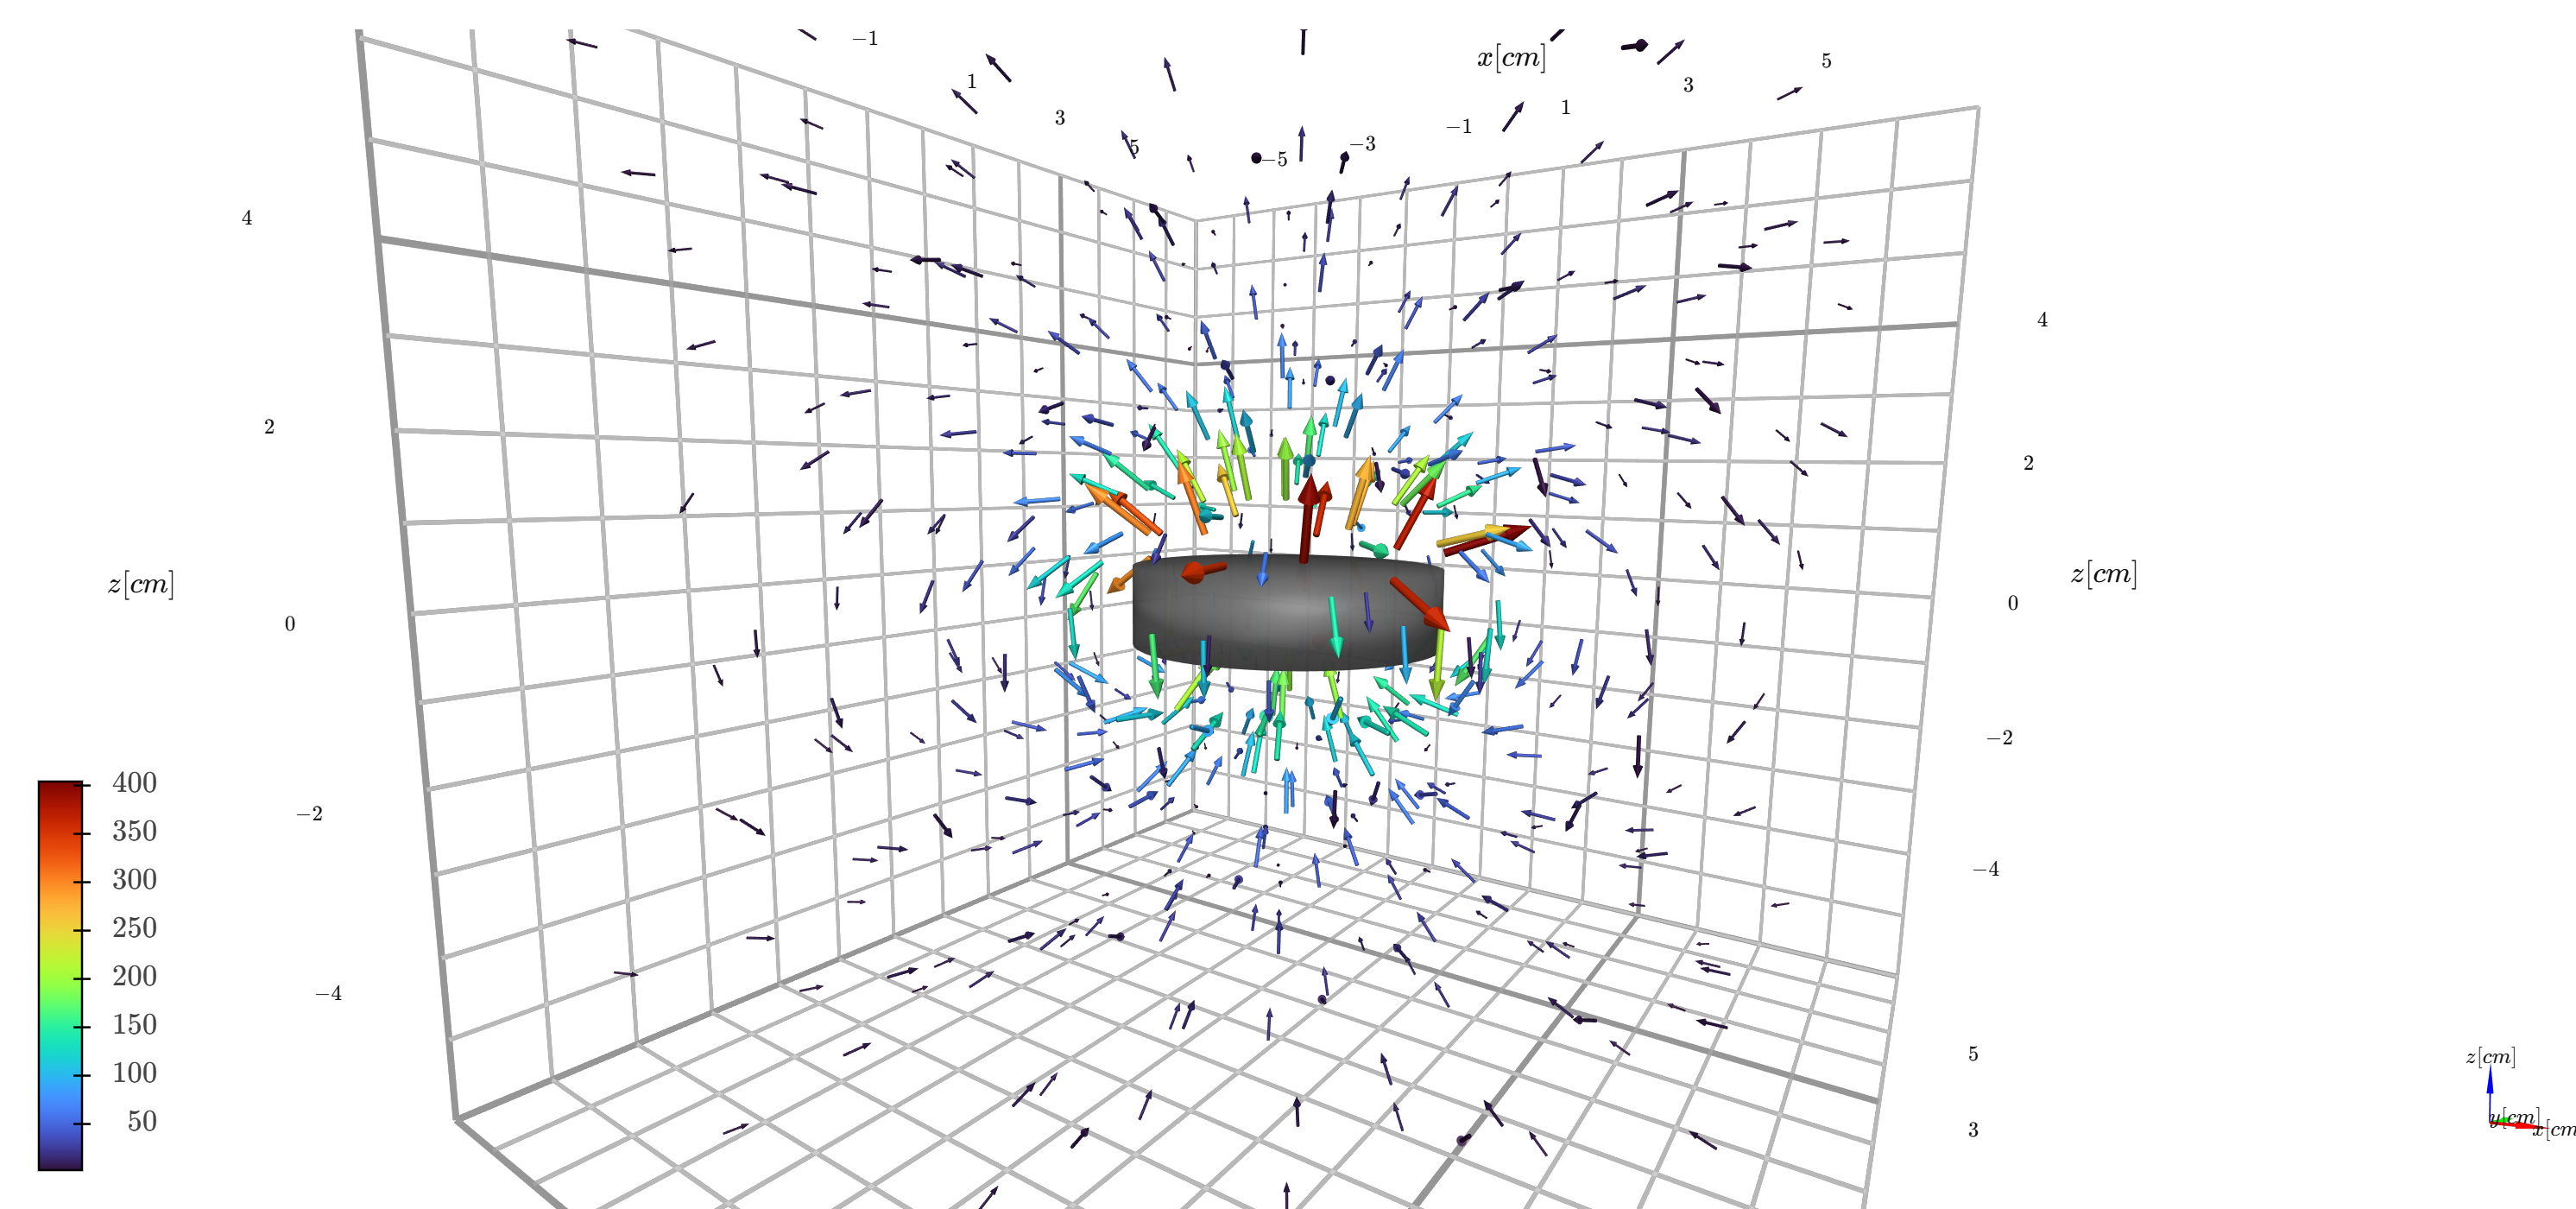